# 04 — Avaliação e Interpretação

Avaliação do modelo selecionado no conjunto de teste e análise das consequências dos resultados para a decisão de crédito.

In [17]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

RANDOM_STATE = 42
PROCESSED = Path("..") / "data" / "processed"
RESULTS = Path("..") / "results"
FIGURES = RESULTS / "figures"
METRICS = RESULTS / "metrics"
MODELS = RESULTS / "models"
TARGET = "TARGET"

FIGURES.mkdir(parents=True, exist_ok=True)
METRICS.mkdir(parents=True, exist_ok=True)
pd.set_option("display.max_columns", None)

## 1. Resultado no conjunto de teste

Aqui verifico como o modelo escolhido se saiu nos dados que não foram usados para treiná-lo. Como há poucos maus pagadores, olhar apenas a acurácia pode dar uma impressão melhor do que o resultado real.

In [18]:
import joblib
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split

# Uso a mesma separação do notebook 03 e carrego o modelo que ele salvou.
df = pd.read_csv(PROCESSED / "dataset_tratado.csv")
X = df.drop(columns=[TARGET, "ID"])
y = df[TARGET].astype(int)
_, X_test, _, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)
best_model = joblib.load(MODELS / "best_model.joblib")

# Alguns modelos dão probabilidades; a SVM retorna uma pontuação equivalente.
if hasattr(best_model, "predict_proba"):
    y_score = best_model.predict_proba(X_test)[:, 1]
else:
    y_score = best_model.decision_function(X_test)
y_pred = best_model.predict(X_test)

print(classification_report(y_test, y_pred, target_names=["Bom pagador", "Mau pagador"], zero_division=0))
metricas_teste = pd.DataFrame([{
    "Modelo": type(best_model.named_steps["model"]).__name__,
    "Acurácia": accuracy_score(y_test, y_pred),
    "Precisão (mau pagador)": precision_score(y_test, y_pred, zero_division=0),
    "Recall (mau pagador)": recall_score(y_test, y_pred, zero_division=0),
    "F1 (mau pagador)": f1_score(y_test, y_pred, zero_division=0),
    "ROC AUC": roc_auc_score(y_test, y_score),
    "Average precision": average_precision_score(y_test, y_score),
}])
display(metricas_teste.round(3))
metricas_teste.to_csv(METRICS / "metricas_teste.csv", index=False)

              precision    recall  f1-score   support

 Bom pagador       0.99      0.98      0.98     10753
 Mau pagador       0.20      0.35      0.26       185

    accuracy                           0.97     10938
   macro avg       0.60      0.66      0.62     10938
weighted avg       0.98      0.97      0.97     10938



,Modelo,Acurácia,Precisão (mau pagador),Recall (mau pagador),F1 (mau pagador),ROC AUC,Average precision
0,RandomForestClassifier,0.966,0.204,0.346,0.257,0.762,0.147


## 2. O que significam as métricas

Recall mostra quantos dos maus pagadores o modelo conseguiu encontrar. Precisão mostra quantos dos clientes apontados pelo modelo eram realmente maus pagadores. F1 junta essas duas medidas em um único valor. ROC AUC e average precision ajudam a comparar a capacidade do modelo de separar as classes quando mudamos o ponto de corte usado para classificá-las.

## 3. Erros do modelo e curva ROC

A matriz mostra quantos clientes foram classificados corretamente e quantos foram confundidos. A curva ROC mostra como os acertos e erros mudam quando ajustamos o ponto de corte usado pelo modelo.

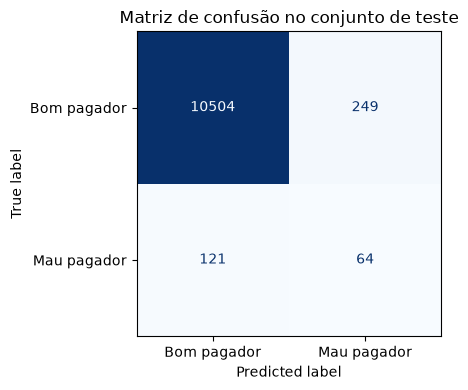

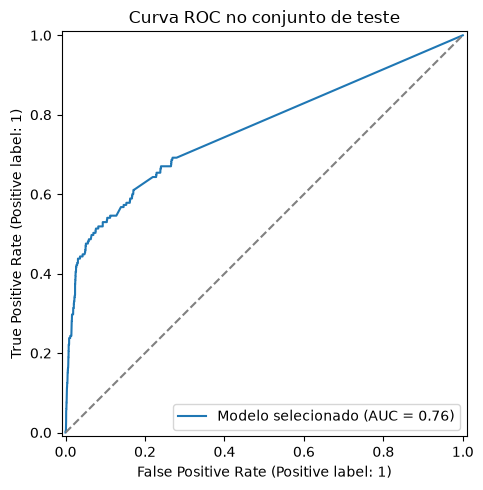

In [19]:
fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["Bom pagador", "Mau pagador"],
    cmap="Blues", values_format="d", colorbar=False, ax=ax
)
ax.set_title("Matriz de confusão no conjunto de teste")
fig.tight_layout()
fig.savefig(FIGURES / "06_matriz_confusao.png", dpi=160, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, y_score, name="Modelo selecionado", ax=ax)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray")
ax.set_title("Curva ROC no conjunto de teste")
fig.tight_layout()
fig.savefig(FIGURES / "07_curva_roc.png", dpi=160, bbox_inches="tight")
plt.show()

**O que observei:** no teste, a ROC AUC foi 0,762 e a average precision foi 0,147. Essas medidas resumem como o modelo separa os dois grupos. A matriz ajuda a ver os maus pagadores que passaram despercebidos e os bons pagadores que foram sinalizados por engano. O ponto de corte atual é 0,5, mas ele pode ser ajustado conforme o custo desses erros.

## 4. Quais informações mais influenciaram o modelo


,Variável,Importância
2,numeric__DAYS_BIRTH,0.192420
3,numeric__DAYS_EMPLOYED,0.148707
1,numeric__AMT_INCOME_TOTAL,0.146363
7,numeric__CNT_FAM_MEMBERS,0.039404
5,numeric__FLAG_PHONE,0.028224
0,numeric__CNT_CHILDREN,0.027809
4,numeric__FLAG_WORK_PHONE,0.021268
23,categorical__NAME_EDUCATION_TYPE_Secondary / s...,0.020143
42,categorical__OCCUPATION_TYPE_Outros,0.019724
10,categorical__FLAG_OWN_CAR_N,0.019272


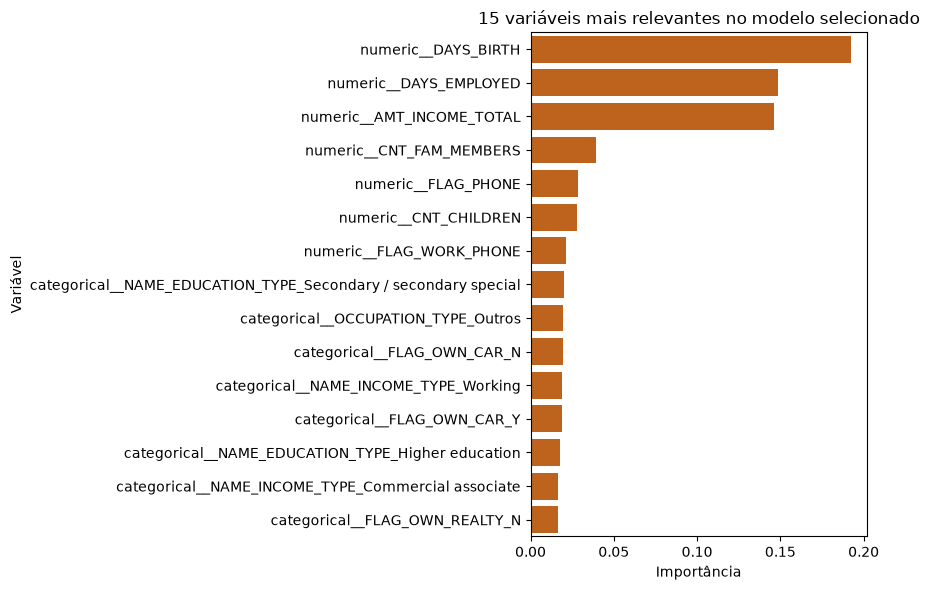

In [20]:
preprocessor = best_model.named_steps["preprocessor"]
classifier = best_model.named_steps["model"]
feature_names = preprocessor.get_feature_names_out()

if hasattr(classifier, "feature_importances_"):
    importances = classifier.feature_importances_
    criterio = "Importância"
else:
    importances = abs(classifier.coef_[0])
    criterio = "Coeficiente absoluto"

feature_importance = pd.DataFrame({
    "Variável": feature_names,
    criterio: importances,
}).sort_values(criterio, ascending=False)
display(feature_importance.head(15))

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(data=feature_importance.head(15), x=criterio, y="Variável", color="#d95f02", ax=ax)
ax.set_title("15 variáveis mais relevantes no modelo selecionado")
fig.tight_layout()
fig.savefig(FIGURES / "08_importancia_variaveis.png", dpi=160, bbox_inches="tight")
plt.show()

feature_importance.to_csv(METRICS / "importancia_variaveis.csv", index=False)

**O que observei:** idade, tempo de emprego e renda tiveram maior influência nas decisões da Random Forest. Isso não quer dizer que essas informações causem inadimplência; apenas foram úteis para o modelo nesta base. Como ele ainda comete erros, esses resultados não devem ser usados como regras definitivas.

## 5. O que isso pode significar para o banco

No teste, o modelo encontrou 64 dos 185 maus pagadores (recall de 35%) e sinalizou por engano 249 bons pagadores. Entre os clientes que ele marcou como maus pagadores, 1 em cada 5 realmente pertencia a esse grupo (precisão de 20%). O modelo pode ajudar a revisar casos, mas não deve decidir sozinho quem recebe crédito. O banco também precisa decidir quanto aceita errar para cada lado e qual ponto de corte faz sentido.


## 6. Limitações

O alvo foi criado a partir dos atrasos disponíveis, e as informações sobre os clientes são principalmente cadastrais. Uma divisão aleatória dos dados pode não representar clientes de outros períodos. Além disso, a influência de uma variável no modelo não prova que ela cause o resultado. Antes de usar o modelo na prática, seria importante testá-lo em dados de outros períodos, conferir se suas estimativas são confiáveis e verificar se funciona de forma justa para diferentes grupos de clientes.